In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Interacting with Mock Cubes via SimIM

The workbook contains some examples of how SimIM can be used to work with the mock
data cubes I've generated for TIM.

Running it requires loading the mock cubes generated by ``1.1_making_a_tim_light_cone_and_cube.ipynb``.

## Making Power Spectra

The following code makes a power spectrum out of the central third of the TIM bandpass for a
field of 0.1 square degrees (analogous to GOODS-S). It iterates through the cubes for the 
uncontaminated signal from CII, both NII lines, and OIII and computes the power spectrum of
each, projected into the correct k-space for the CII line. It also computes the power spectrum
for the cube containing all 4 lines, to show how the different lines contribute to the total
power.

Because our cubes are at a higher resolution than TIM can produce, these power spectrum
estimates don't account for attenuation of the signal at high k by either the shape of 
the beam or the spectral response.

In [27]:
# Some parameters for TIM
# We'll just analyze the center 1/3 of the bandpass
fmin = 2.998e8 / 360e-6 # Hz
fmax = 2.998e8 / 300e-6
fmid = (fmin+fmax)/2
fcii = 1900.5369e9 # Hz

# Cosmology stuff
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
h = 0.6774   # Value of little h appropriate for TNG simulations
cosmo = FlatLambdaCDM(H0=100*h*(u.km/u.Mpc/u.s), Om0=0.309, Tcmb0=2.725*u.K, Neff=3.04, Ob0=0.0486)

In [31]:
# Load each grid and compute the power spectrum
from simim.map import load_grid

paths = ['tim_grid_full_res.npz','tim_grid_cii_full_res.npz','tim_grid_nii205_full_res.npz','tim_grid_nii122_full_res.npz','tim_grid_oiii_full_res.npz']
names = ['Total Power','CII','NII 205um','NII 122um','OIII']

power_spectra = {}
for path, name in zip(paths,names):
    # Load the grid
    grid = load_grid(path)

    # Crop grid to central 1/3 of TIM frequency coverage
    grid.crop(ax=2,min=2.998e8/360e-6,max=2.998e8/300e-6)

    # Crop sides to produce a 0.1 square degree field
    l = np.sqrt(0.1) * np.pi/180
    grid.crop(ax=0,min=-l/2,max=l/2)
    grid.crop(ax=0,min=-l/2,max=l/2)

    # Compute the power spectrum of the grid
    grid.power_spectrum(normalize=False,in_place=True)

    # Convert axes from uveta to k space - using transform apropriate for CII
    z_cii_mid = fcii / fmid - 1
    xfactor = cosmo.comoving_distance(z_cii_mid).value
    yfactor = 2.998e8/fcii * (1+z_cii_mid)**2 / (1000*cosmo.H(z_cii_mid).value)

    grid.fourier_axes[0] = 2*np.pi*grid.fourier_axes[0] / xfactor / h
    grid.fourier_axes[1] = 2*np.pi*grid.fourier_axes[1] / xfactor / h
    grid.fourier_axes[2] = 2*np.pi*grid.fourier_axes[2] / yfactor / h
    grid.fourier_axes_centers[0] = 2*np.pi*grid.fourier_axes_centers[0] / xfactor / h
    grid.fourier_axes_centers[1] = 2*np.pi*grid.fourier_axes_centers[1] / xfactor / h
    grid.fourier_axes_centers[2] = 2*np.pi*grid.fourier_axes_centers[2] / yfactor / h

    # Normalize power spectrum - units will be (Jy/Str)^2 Mpc^3 h^-3
    v = np.prod(grid.side_length) * xfactor**2 * yfactor
    grid.grid = grid.grid * (np.prod(grid.pixel_size) * xfactor**2 * yfactor)**2
    grid.grid = grid.grid / v * h**3

    # Do a spherical average
    k_edges,ps1d,n1d = grid.spherical_average(ax=[0,1,2],bins=np.logspace(-3,3,31),return_n=True)

    power_spectra[name] = ps1d.flatten()

k_centers = np.logspace(-2.9,2.9,30)
n1d = n1d.flatten()


/Users/rpkeenan/Dropbox/4_research/2.1_simim/simim/map/gridder.py:1085: RuntimeWarning: invalid value encountered in true_divide
  binned_averages /= binned_weights


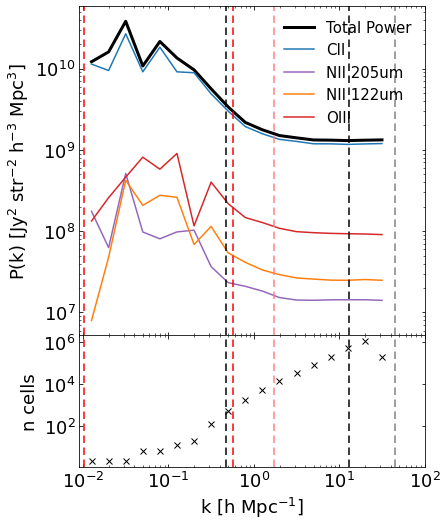

In [42]:
# Plot the power spectrum
fig = plt.figure(figsize=(6,8))
gs = fig.add_gridspec(2, 1,  height_ratios=(5,2),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0, hspace=0)
ax = fig.add_subplot(gs[0])
ax_n = fig.add_subplot(gs[1])
ax_n.sharex(ax)
plt.setp(ax.get_xticklabels(),visible=False)

ax.set(ylabel='P(k) [Jy$^2$ str$^{-2}$ h$^{-3}$ Mpc$^3$]',xscale='log',yscale='log',xlim=(9e-3,100))
ax_n.set(xlabel='k [h Mpc$^{-1}$]',ylabel='n cells',yscale='log',yticks=[1e2,1e4,1e6])

ax.plot(k_centers,power_spectra['Total Power'],label='Total Power',color='k',lw=3)
for name,color in zip(['CII','NII 205um','NII 122um','OIII'],['C0','C4','C1','C3']):
    ax.plot(k_centers,power_spectra[name],label=name,color=color)
ax.legend(fontsize='small')

ax_n.plot(k_centers,n1d,color='k',ls='none',marker='x')

for a in [ax,ax_n]:
    a.axvline(2*np.pi/(grid.pixel_size[0]*xfactor*h),color='.5',ls='--')
    a.axvline(2*np.pi/(1.2*330e-6/2*xfactor*h),color='k',ls='--')
    a.axvline(2*np.pi/(grid.side_length[0]*xfactor*h),color='k',ls='--')

    a.axvline(2*np.pi/(grid.pixel_size[2]*yfactor*h),color=(1,.5,.5),ls='--')
    a.axvline(2*np.pi/(2.998e8/330e-6/300*yfactor*h),color='r',ls='--')
    a.axvline(2*np.pi/(grid.side_length[2]*yfactor*h),color='r',ls='--')